# FIT5196 Assessment 1 — Group005 EDA

**Group:** Group005  
**Members:**
 - Gia Linh (Sally) Vu - 36071668
 - ..
 - ..
 - ..
 - ..

Exploratory analysis of the six standardised tables frozen by the Task 2 pipeline
(`orders` 5,000 - `order_items` 15,739 - `deliveries` 5,000 - `product_reviews` 7,000 -
`customers` 500 - `products` 1,000). This notebook is the reproducibility evidence
for `Group005_EDA.pdf`: eight assessed figures covering the six required categories,
drawing on all six tables and five relational joins, followed by ten evidence-based
findings and five future ML questions.

**Overview:** The analysis identifies four substantive business patterns: **basket composition drives order value; the Nicholson warehouse has stronger on-time delivery performance; delivery generates a small but positive profit contribution; and stated value perception is the only material correlate of ratings.** However, these findings must be interpreted within clear limits imposed by four independent synthetic-data signatures: bounded business hours, near-flat day-of-week volume, uniform helpful-vote counts, and historical customer attributes that do not predict observed behaviour. Each figure therefore serves a specific analytical purpose: to establish a real pattern, expose a synthetic-data signature, or test and reject a plausible but unsupported hypothesis. All relationships are reported as **associations, not causal effects**.


## 0. Configuration and data loading

The six CSVs are loaded with `keep_default_na=False` so the pipeline's literal `NaN` token stays visible (turning it into a real missing value would corrupt every coupon/promo denominator), and `dtype=str` so identifiers keep their leading zeros; numeric columns are cast explicitly at point of use. Row counts and primary-key uniqueness are checked live so the notebook fails loudly if pointed at the wrong export. The EDA reads **only** these frozen CSVs without re-running completed cleaning or re-importing the solution modules.

In [1]:
import pandas as pd, numpy as np
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import TwoSlopeNorm
from scipy import stats
from itertools import combinations
from collections import Counter
from pathlib import Path
from IPython.display import display
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline

# Defines the consistent, colour-blind-safe house style (Okabe–Ito) to be reused throughout the file
OK = {'black':'#000000','orange':'#E69F00','sky':'#56B4E9','green':'#009E73',
      'yellow':'#F0E442','blue':'#0072B2','verm':'#D55E00','purple':'#CC79A7','grey':'#8C8C8C'}
SEG = [OK['blue'], OK['orange'], OK['green'], OK['purple']]     # fixed categorical order

# Ensure all 8 figures are consistent in visual system
mpl.rcParams.update({
    'figure.dpi':110, 'savefig.dpi':110, 'savefig.bbox':'tight',
    'font.size':10.5, 'axes.titlesize':11.5, 'axes.titleweight':'bold', 'axes.labelsize':10.5,
    'axes.spines.top':False, 'axes.spines.right':False,
    'axes.grid':True, 'grid.alpha':0.22, 'grid.linewidth':0.6, 'legend.frameon':False})
def aud(x, _): return f'${x/1000:,.0f}k' if abs(x)>=1000 else f'${x:,.0f}'

# Define two small statistical helpers (used across figures)
def wilson(k, n, z=1.96):
    if n == 0: return (np.nan, np.nan, np.nan)
    p = k/n; d = 1 + z*z/n
    c = (p + z*z/(2*n))/d; h = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n))/d
    return p, c-h, c+h
def two_prop_z(k1, n1, k2, n2):
    p1, p2 = k1/n1, k2/n2; p = (k1+k2)/(n1+n2)
    se = np.sqrt(p*(1-p)*(1/n1 + 1/n2)); z = (p1-p2)/se
    return z, 2*(1 - stats.norm.cdf(abs(z)))
print('Environment ready — pandas', pd.__version__)

Environment ready — pandas 2.3.3


In [2]:
OPTS = dict(keep_default_na=False, dtype=str)   # literal 'NaN' stays a token; IDs stay strings
CANDIDATES = ['outputs', 'task2_output', '../outputs', '../task2_output']
DATA_DIR = next((Path(d) for d in CANDIDATES
                 if (Path(d)/'Group005_orders_standardised.csv').exists()), None)
assert DATA_DIR is not None, "Six standardised CSVs not found in outputs/ or task2_output/."
print('Reading from:', DATA_DIR.resolve(), '\n')

def load(name): 
    return pd.read_csv(DATA_DIR/f'Group005_{name}_standardised.csv', **OPTS)
orders      = load('orders')
order_items = load('order_items')
deliveries  = load('deliveries')
reviews     = load('product_reviews')
customers   = load('customers')
products    = load('products')

# numeric casts at point of use (IDs deliberately left as strings)
CAST = {
 'orders':      ['order_price','delivery_charges','coupon_discount','tax_amount','order_total','customer_lat','customer_long'],
 'order_items': ['quantity','unit_price','line_revenue'],
 'deliveries':  ['delay_days','fulfilment_hours','delivery_cost','promised_days','tracking_event_count','shipping_distance_km','estimated_carbon_kg'],
 'reviews':     ['rating','helpful_votes','review_length_chars','review_word_count'],
 'customers':   ['prior_12m_orders','lifetime_value_before_period'],
 'products':    ['unit_price','unit_cost','launch_year','warranty_months','weight_kg'],
}
for df, cols in [(orders,CAST['orders']),(order_items,CAST['order_items']),(deliveries,CAST['deliveries']),
                 (reviews,CAST['reviews']),(customers,CAST['customers']),(products,CAST['products'])]:
    for c in cols: 
        df[c] = pd.to_numeric(df[c], errors='coerce')
        
orders['order_dt']    = pd.to_datetime(orders['order_timestamp'],  errors='coerce')
reviews['review_dt']  = pd.to_datetime(reviews['review_timestamp'], errors='coerce')
deliveries['delivered_dt'] = pd.to_datetime(deliveries['delivered_date'], errors='coerce')

# live row-count + PK-uniqueness check
checks = [('orders',orders,'order_id',5000),('order_items',order_items,'order_item_id',15739),
          ('deliveries',deliveries,'delivery_id',5000),('product_reviews',reviews,'review_id',7000),
          ('customers',customers,'customer_id',500),('products',products,'product_id',1000)]
print(f"{'table':16s}{'rows':>7s}{'expected':>10s}{'PK unique':>12s}")
for name, df, pk, exp in checks:
    print(f"{name:16s}{len(df):>7d}{exp:>10d}{str(df[pk].is_unique):>12s}")
assert all(len(df)==exp and df[pk].is_unique for _,df,pk,exp in checks), "row-count / PK check failed"
print('\nAll six tables loaded at expected grain with unique primary keys.')

Reading from: /Users/chipi/Desktop/MONASH/Sem2_26/FIT5196/assignments/A1_group/task2_output 

table              rows  expected   PK unique
orders             5000      5000        True
order_items       15739     15739        True
deliveries         5000      5000        True
product_reviews    7000      7000        True
customers           500       500        True
products           1000      1000        True

All six tables loaded at expected grain with unique primary keys.


table              rows  expected   PK unique
orders             5000      5000        True
order_items       15739     15739        True
deliveries         5000      5000        True
product_reviews    7000      7000        True
customers           500       500        True
products           1000      1000        True

All six tables loaded at expected grain with unique primary keys.


## 1. Context and data-preparation assurance

**Business context.** A Victorian multi-channel electronics retailer's 2018 trading
year, reconciled from two source systems (a JSON commerce export and an XML operations
export) into six analysis-ready tables. The analytical unit differs by question —
orders, order items, deliveries, reviews, customers, or products — and every figure
below states its grain and denominator explicitly.

**Preparation assurance (cited, not repeated).** The build is trustworthy on the
points this EDA leans on:

* **Grain & keys** — primary keys are 100% unique on all six tables (`VAL-PK-orders`,
  `VAL-PK-deliveries`, `VAL-PK-product_reviews`); `deliveries` is 1:1 with `orders` in
  this export because every order is Completed/Delivered (`VAL-GRAIN-deliveries`).
* **Referential integrity** — 0 orphans across the join graph
  (`VAL-FK-order_items`, `VAL-FK-deliveries`, `VAL-FK-product_reviews`), so every join
  drawn below is safe from missing-parent artefacts.
* **Arithmetic contract** — `Σ line_revenue == order_price` per order and
  `tax = price/11` reconcile exactly (`VAL-MONEY-01…VAL-MONEY-04`), which is what lets
  the anti-double-count guard in §1.1 hold.
* **Reconciliation** — cross-source overlap agreed on every field after normalisation,
  so union kept one canonical row with no precedence rule and 0 logged conflicts
  (`VAL-CONFLICT-01`; keys `MAP-orders-01`, `MAP-orders-04`).
* **Missingness & text** — empty coupons are the literal token `NaN`
  (`VAL-SENTINEL-coupon_code`), and review text / references were cleaned and
  cross-validated (`VAL-TEXT-01…VAL-TEXT-05`); order→review timing is sane, 0 reviews
  precede their order (`VAL-TIME-delivery`).

The two guard cells below (§1.1 grain, §1.2 synthetic signatures) are the frame every
later figure is read against.

### 1.1 Anti-double-count guard (grain gate)

The single most dangerous mistake in this schema is summing an order-level metric
across a one-to-many child join. The cell below proves the trap quantitatively once;
every revenue figure afterwards states the grain it uses and never sums a parent
metric across a child.

In [3]:
rev_order   = orders['order_total'].sum()
joined      = orders.merge(order_items[['order_id']], on='order_id', how='inner')
rev_inflated = orders.set_index('order_id').loc[joined['order_id'], 'order_total'].sum()
line_rev    = order_items['line_revenue'].sum()
per_order_ok = int((np.abs(order_items.groupby('order_id')['line_revenue'].sum().round(2)
                          - orders.set_index('order_id')['order_price'].round(2)) <= 0.01).sum())

guard = pd.DataFrame({
    'quantity': ['SUM(order_total) at ORDER grain  (correct)',
                 'SUM(order_total) after orders × order_items  (WRONG)',
                 'SUM(line_revenue) at ITEM grain  (gross line revenue)',
                 'orders where Σ line_revenue == order_price (tol 0.01)'],
    'value':    [f'${rev_order:,.2f}', f'${rev_inflated:,.2f}',
                 f'${line_rev:,.2f}', f'{per_order_ok:,} / {len(orders):,}']})
display(guard)
print(f"Naive orders×items join inflates revenue ×{rev_inflated/rev_order:.2f} "
      f"(mean {len(order_items)/len(orders):.2f} items/order). "
      f"All revenue metrics below are computed at their intended grain.")

,quantity,value
0,SUM(order_total) at ORDER grain (correct),"$14,290,607.87"
1,SUM(order_total) after orders × order_items (...,"$50,601,097.01"
2,SUM(line_revenue) at ITEM grain (gross line r...,"$15,795,015.08"
3,orders where Σ line_revenue == order_price (to...,"5,000 / 5,000"


Naive orders×items join inflates revenue ×3.54 (mean 3.15 items/order). All revenue metrics below are computed at their intended grain.


### 1.2 Synthetic-data signatures (interpretation gate)

Four independent quantities are far flatter or more disconnected than any real
e-commerce dataset would produce. Measured together they are the evidence for
**Finding 1** and the reason every business reading below is framed as a description of
*this dataset*, not a generalisable claim.

In [4]:
hours   = orders['order_dt'].dt.hour
dow_ct  = orders['order_dt'].dt.day_name().value_counts()
hv_buck = pd.cut(reviews['helpful_votes'], bins=np.arange(0,100,10), right=False).value_counts().sort_index()
chi_hv, p_hv = stats.chisquare(hv_buck.values)
cust_obs = orders.groupby('customer_id')['order_id'].size()
r_hist   = customers.set_index('customer_id')['prior_12m_orders'].reindex(cust_obs.index).corr(cust_obs)
r_ltv    = customers.set_index('customer_id')['lifetime_value_before_period'].reindex(cust_obs.index).corr(
           orders.groupby('customer_id')['order_total'].sum())

meta = pd.DataFrame({
 'signature': ['Hours of day with any orders','Day-of-week volume spread',
               'helpful_votes shape (9 buckets of 10)','Historical vs observed customer behaviour'],
 'measured':  [f'{hours.nunique()} of 24 (08:00–21:59)',
               f'{(dow_ct.max()-dow_ct.min())/dow_ct.mean()*100:.1f}%  ({dow_ct.min()}–{dow_ct.max()}/day)',
               f'uniform: χ²={chi_hv:.1f}, p={p_hv:.2f} (counts {hv_buck.min()}–{hv_buck.max()})',
               f'r(prior_12m, observed orders)={r_hist:.2f}; r(LTV, observed rev)={r_ltv:.2f}'],
 'real data would show': ['24h incl. late-night','clear weekend effect',
                          'heavy right tail','persistent, r≫0']})
display(meta)
print("Four independent flat/disconnected signals → treat findings as dataset-descriptive.")

,signature,measured,real data would show
0,Hours of day with any orders,14 of 24 (08:00–21:59),24h incl. late-night
1,Day-of-week volume spread,2.5% (702–720/day),clear weekend effect
2,helpful_votes shape (9 buckets of 10),"uniform: χ²=3.1, p=0.93 (counts 746–802)",heavy right tail
3,Historical vs observed customer behaviour,"r(prior_12m, observed orders)=0.05; r(LTV, obs...","persistent, r≫0"


Four independent flat/disconnected signals → treat findings as dataset-descriptive.


## 2. Assessed EDA visualisations

Eight assessed figures. The set covers all six published categories, draws on **all
six tables** and **five relational joins**, and shows the anti-double-count guard once
(§1.1). Only the first eight figures are marked.

| Fig | Category | Grain / n | Tables | Join key(s) |
|---|---|---|---|---|
| 1 | 1 Univariate | order / 5,000 | orders | — |
| 2 | 2 Bivariate | review / 7,000 | product_reviews - deliveries | reviews.order_id = deliveries.order_id (many-to-1) |
| 3 | 3 Multivariate | order / 5,000 - customer / 500 | order_items(agg) - orders - customers | agg by order_id → order_id → customer_id |
| 4 | 4 Temporal | order / 5,000 | orders | — |
| 5 | 5 Review/text | review / 7,000 | product_reviews | — |
| 6 | 6 Delivery/ops | delivery / 5,000 | deliveries - orders | deliveries.order_id = orders.order_id (1:1) |
| 7 | reinforces 6 | delivery / 5,000 | deliveries - orders | deliveries.order_id = orders.order_id (1:1) |
| 8 | reinforces 3 | category pair / 5,000 orders | order_items - products | items.product_id = products.product_id |

**Coverage:** 6/6 categories - 6/6 tables - 5 joins (≥2) - grain + denominator stated per figure.

### Figure 1: Univariate distribution or composition

**Question:** How is order value distributed, and how concentrated is total revenue?
**Observation unit / denominator:** one row per order; n = 5,000.
**Tables / join keys:** orders only (no join).
**Interpretation / limitation:** see below the figure.

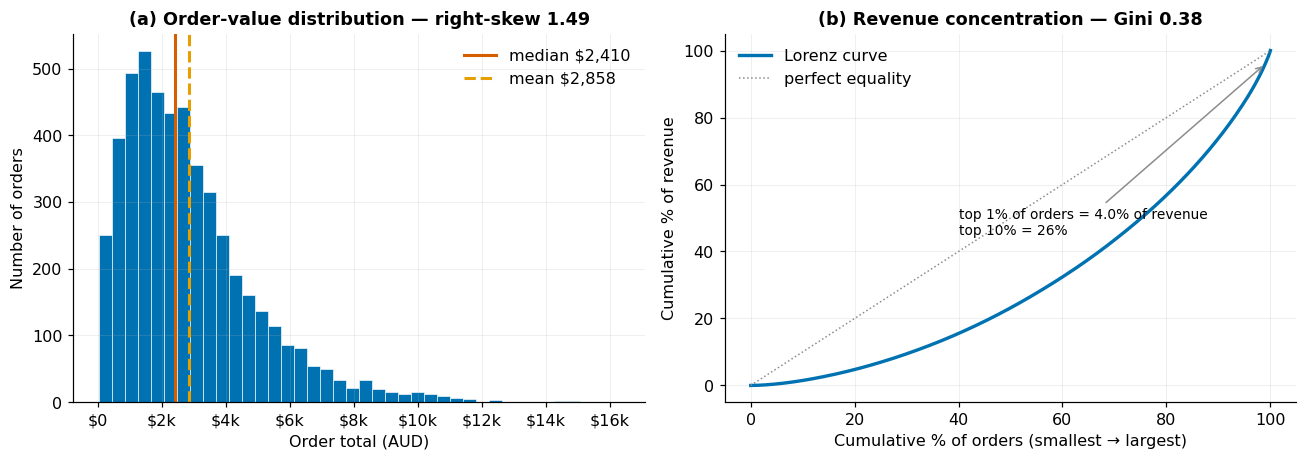

median $2,410 | mean $2,858 | skew 1.49 | p90 $5,605 | p99 $10,098 | max $16,282
top 1% = 4.0% of revenue | top 10% = 26.2% | Gini 0.385


In [5]:
ot = orders['order_total']
x = np.sort(ot.values); n = len(x)
gini = (2*np.sum(np.arange(1,n+1)*x)/(n*x.sum())) - (n+1)/n
cum_rev = np.cumsum(x)/x.sum(); cum_ord = np.arange(1,n+1)/n
top1 = x[int(np.ceil(0.99*n)):].sum()/x.sum()*100
top10 = x[int(np.ceil(0.90*n)):].sum()/x.sum()*100

fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ax[0].hist(ot, bins=40, color=OK['blue'], edgecolor='white', linewidth=0.4)
ax[0].axvline(ot.median(), color=OK['verm'], lw=2, label=f"median ${ot.median():,.0f}")
ax[0].axvline(ot.mean(), color=OK['orange'], lw=2, ls='--', label=f"mean ${ot.mean():,.0f}")
ax[0].set(xlabel='Order total (AUD)', ylabel='Number of orders',
          title=f'(a) Order-value distribution — right-skew {ot.skew():.2f}')
ax[0].xaxis.set_major_formatter(FuncFormatter(aud)); ax[0].legend()

ax[1].plot(cum_ord*100, cum_rev*100, color=OK['blue'], lw=2.2, label='Lorenz curve')
ax[1].plot([0,100],[0,100], color=OK['grey'], lw=1, ls=':', label='perfect equality')
ax[1].set(xlabel='Cumulative % of orders (smallest → largest)',
          ylabel='Cumulative % of revenue',
          title=f'(b) Revenue concentration — Gini {gini:.2f}')
ax[1].annotate(f'top 1% of orders = {top1:.1f}% of revenue\ntop 10% = {top10:.0f}%',
               xy=(99, 100-top1), xytext=(40, 45), fontsize=9,
               arrowprops=dict(arrowstyle='->', color=OK['grey']))
ax[1].legend(loc='upper left')
fig.tight_layout(); plt.show()
print(f"median ${ot.median():,.0f} | mean ${ot.mean():,.0f} | skew {ot.skew():.2f} | "
      f"p90 ${ot.quantile(.9):,.0f} | p99 ${ot.quantile(.99):,.0f} | max ${ot.max():,.0f}")
print(f"top 1% = {top1:.1f}% of revenue | top 10% = {top10:.1f}% | Gini {gini:.3f}")

**Interpretation.** Order value is right-skewed (skew 1.49; mean \$2,858 above median
\$2,410) but **not** heavy-tailed: the largest 1% of orders (n = 50) hold only 4.0% of
revenue and the top 10% about 26% (Gini 0.39). **Limitation:** the mild mean–median gap
could be a data-generation choice rather than genuine buyer heterogeneity — hence
medians are used for AOV comparisons elsewhere (supports Finding 8).

### Figure 2: Bivariate relationship or group comparison

**Question:** Which factor is associated with higher review ratings — stated
value-experience, delivery outcome, or review length?
**Observation unit / denominator:** one row per review; n = 7,000 (on-time 6,258 /
delayed 742; good_value 6,118 / poor_value 882).
**Tables / join keys:** product_reviews ⋈ deliveries on `order_id` (many-to-one: each
review's order maps to exactly one delivery). **Join #1.**
**Interpretation / limitation:** see below the figure.

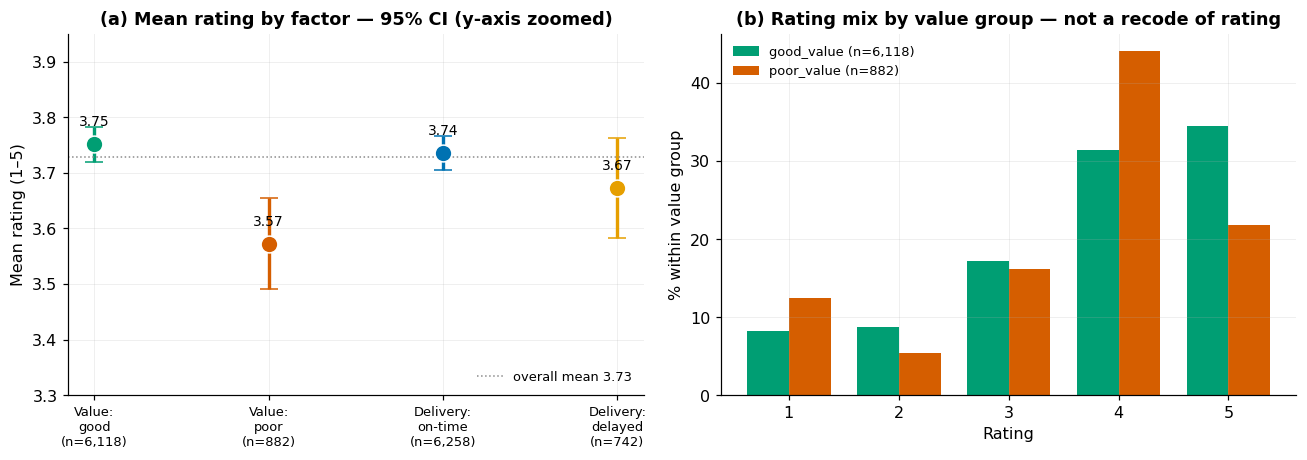

value gap = 0.179  (Welch t=4.00, p=6.7e-05)
delivery gap (on-time − delayed) = 0.063
rating × review_length r = -0.043 | rating × helpful_votes r = 0.000
tautology check — poor_value reviews rated ≥4★: 581 / 882


In [6]:
rj = reviews.merge(deliveries[['order_id','on_time_in_full']], on='order_id', how='left')
assert rj['on_time_in_full'].isna().sum() == 0
def mci(s): m=s.mean(); return m, 1.96*s.std()/np.sqrt(len(s)), len(s)
groups = [('Value:\ngood', reviews.loc[reviews.value_experience=='good_value','rating'], OK['green']),
          ('Value:\npoor', reviews.loc[reviews.value_experience=='poor_value','rating'], OK['verm']),
          ('Delivery:\non-time', rj.loc[rj.on_time_in_full=='True','rating'], OK['blue']),
          ('Delivery:\ndelayed', rj.loc[rj.on_time_in_full=='False','rating'], OK['orange'])]
overall = reviews['rating'].mean()

fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
for i,(lab,s,c) in enumerate(groups):
    m,e,nn = mci(s)
    ax[0].errorbar(i, m, yerr=e, fmt='o', ms=11, color=c, mec='white', elinewidth=2.2, capsize=6)
    ax[0].annotate(f'{m:.2f}', (i, m), xytext=(0,12), textcoords='offset points', ha='center', fontsize=9)
ax[0].axhline(overall, color=OK['grey'], ls=':', lw=1, label=f'overall mean {overall:.2f}')
ax[0].set_xticks(range(4)); ax[0].set_xticklabels([f"{l}\n(n={mci(s)[2]:,})" for l,s,_ in groups], fontsize=8.5)
ax[0].set(ylabel='Mean rating (1–5)', ylim=(3.30,3.95),
          title='(a) Mean rating by factor — 95% CI (y-axis zoomed)')
ax[0].legend(loc='lower right', fontsize=8.5)

ct = pd.crosstab(reviews['value_experience'], reviews['rating'], normalize='index')*100
xx = np.arange(1,6); w = 0.38
ax[1].bar(xx-w/2, ct.loc['good_value'], w, color=OK['green'], label='good_value (n=6,118)')
ax[1].bar(xx+w/2, ct.loc['poor_value'], w, color=OK['verm'], label='poor_value (n=882)')
ax[1].set(xlabel='Rating', ylabel='% within value group', xticks=xx,
          title='(b) Rating mix by value group — not a recode of rating')
ax[1].legend(fontsize=8.5)
fig.tight_layout(); plt.show()

gv = reviews.loc[reviews.value_experience=='good_value','rating']
pv = reviews.loc[reviews.value_experience=='poor_value','rating']
t = stats.ttest_ind(gv, pv, equal_var=False)
print(f"value gap = {gv.mean()-pv.mean():.3f}  (Welch t={t.statistic:.2f}, p={t.pvalue:.1e})")
print(f"delivery gap (on-time − delayed) = {rj.loc[rj.on_time_in_full=='True','rating'].mean()-rj.loc[rj.on_time_in_full=='False','rating'].mean():.3f}")
print(f"rating × review_length r = {reviews['rating'].corr(reviews['review_length_chars']):.3f} | "
      f"rating × helpful_votes r = {reviews['rating'].corr(reviews['helpful_votes']):.3f}")
print(f"tautology check — poor_value reviews rated ≥4★: {int(((reviews.value_experience=='poor_value')&(reviews.rating>=4)).sum())} / 882")

**Interpretation.** Stated value-experience is the only factor with a material,
significant association with rating: good_value 3.75 vs poor_value 3.57 (gap 0.18,
Welch t = 4.0, p < 0.001) — roughly **3× the delivery-lateness gap (0.06, ns)** and far
above the near-zero length correlation (−0.04). Panel (b) shows value_experience is
**not a deterministic recode** of rating: 581 of 882 poor_value reviews still rate ≥4★.
**Limitation:** value_experience and rating are co-reported by the same reviewer
(shared-method variance), so this is association, not evidence that value perception
*drives* the score. `delivery_experience` is the review-side twin of `on_time_in_full`
(742 delayed = 742 late) and is deliberately not counted as separate evidence.

### Figure 3: Multivariate or segmented relationship

**Question:** What characterises high-value orders — basket composition (size, breadth,
item price) or customer identity (segment, prior history)?
**Observation unit / denominator:** order (n = 5,000) for panels (a)–(c); customer
(n = 500) for panel (d).
**Tables / join keys:** `order_items` aggregated to order grain **before** joining to
`orders` (1:1) and `customers` (1:1) — the anti-multiplication rule in action.
**Joins #2 & #3** (double join).
**Interpretation / limitation:** see below the figure.

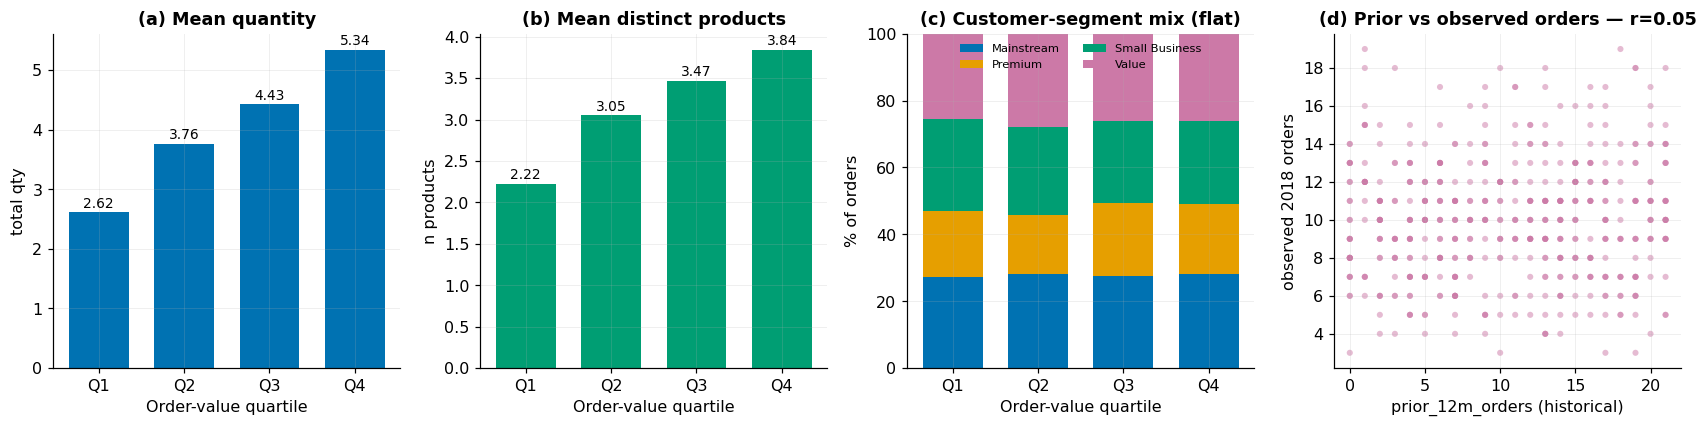

Basket composition by order-value quartile:


,mean quantity,mean distinct products,mean item price ($),mean order total ($)
q,,,,
Q1,2.62,2.22,380.54,791.99
Q2,3.76,3.05,634.03,1855.29
Q3,4.43,3.47,856.41,3043.29
Q4,5.34,3.84,1248.93,5741.92


corr(order_total, avg item price) = 0.731  (> breadth)
corr(order_total, total_qty)      = 0.577
corr(order_total, n_products)     = 0.486
AOV by segment: {'Mainstream': 2905, 'Premium': 2933, 'Small Business': 2788, 'Value': 2820}
corr(prior_12m_orders, observed orders) = 0.051  (historical fields ~ no signal — see Finding 2)


In [7]:
# aggregate the one-to-many child to order grain FIRST, then join 1:1 (never raw items×orders×customers)
agg = (order_items.groupby('order_id')
       .agg(total_qty=('quantity','sum'), n_products=('product_id','nunique'), line_rev=('line_revenue','sum'))
       .reset_index())
o2 = orders[['order_id','order_total','customer_id']].merge(agg, on='order_id', how='left')
assert len(o2) == 5000 and o2['total_qty'].isna().sum() == 0
o2['q'] = pd.qcut(o2['order_total'], 4, labels=['Q1','Q2','Q3','Q4'])
o2['avg_price'] = o2['line_rev']/o2['total_qty']
o3 = o2.merge(customers[['customer_id','customer_segment']], on='customer_id', how='left')

fig, ax = plt.subplots(1, 4, figsize=(15.5, 4))
for a,(col,ttl,c) in zip(ax[:2], [('total_qty','(a) Mean quantity',OK['blue']),
                                  ('n_products','(b) Mean distinct products',OK['green'])]):
    m = o2.groupby('q')[col].mean()
    a.bar(m.index, m.values, color=c, width=0.7)
    for i,v in enumerate(m.values): a.annotate(f'{v:.2f}', (i,v), xytext=(0,3), textcoords='offset points', ha='center', fontsize=9)
    a.set(title=ttl, xlabel='Order-value quartile', ylabel=col.replace('_',' '))

comp = pd.crosstab(o3['q'], o3['customer_segment'], normalize='index')*100
bottom = np.zeros(4)
for i, seg in enumerate(comp.columns):
    ax[2].bar(comp.index, comp[seg], bottom=bottom, color=SEG[i], label=seg, width=0.7)
    bottom += comp[seg].values
ax[2].set(title='(c) Customer-segment mix (flat)', xlabel='Order-value quartile', ylabel='% of orders', ylim=(0,100))
ax[2].legend(fontsize=7.5, loc='upper center', ncol=2)

cust = orders.groupby('customer_id').agg(obs_orders=('order_id','size'), obs_rev=('order_total','sum')).reset_index()
cm = cust.merge(customers[['customer_id','prior_12m_orders']], on='customer_id', how='left')
r = cm['prior_12m_orders'].corr(cm['obs_orders'])
ax[3].scatter(cm['prior_12m_orders'], cm['obs_orders'], s=16, alpha=0.5, color=OK['purple'], edgecolor='none')
ax[3].set(title=f'(d) Prior vs observed orders — r={r:.2f}', xlabel='prior_12m_orders (historical)', ylabel='observed 2018 orders')
fig.tight_layout(); plt.show()

q_tbl = o2.groupby('q')[['total_qty','n_products','avg_price','order_total']].mean().round(2)
q_tbl.columns = ['mean quantity','mean distinct products','mean item price ($)','mean order total ($)']
print("Basket composition by order-value quartile:"); display(q_tbl)
print(f"corr(order_total, avg item price) = {o2['order_total'].corr(o2['avg_price']):.3f}  (> breadth)")
print(f"corr(order_total, total_qty)      = {o2['order_total'].corr(o2['total_qty']):.3f}")
print(f"corr(order_total, n_products)     = {o2['order_total'].corr(o2['n_products']):.3f}")
print("AOV by segment:", {k:round(v) for k,v in o3.groupby('customer_segment')['order_total'].mean().items()})
print(f"corr(prior_12m_orders, observed orders) = {r:.3f}  (historical fields ~ no signal — see Finding 2)")

**Interpretation.** Order value rises monotonically with basket size across quartiles
(mean quantity Q1 2.62 → Q4 5.34; distinct products 2.22 → 3.84), but the **stronger
correlate is average item price (r = 0.73) over quantity (0.58) or breadth (0.49)** — so
high-value orders are driven more by *expensive items* than by simply *more* items.
Customer-segment mix is flat across quartiles (AOV \$2,788–\$2,933, ~5% spread) and
historical order count barely relates to observed orders (r = 0.05, panel d).
**Limitation / alternative:** part of the value–quantity link is mechanical (order value
is computed from line items), so this is observational; the durable, non-mechanical
result is that value is a *basket-composition* property, not a *customer-identity* one
(supports Findings 2 and 3).

### Figure 4: Temporal pattern

**Question:** Are there real temporal rhythms in ordering (hour, weekday, month), or is
the variation unusually flat?
**Observation unit / denominator:** one row per order; n = 5,000; all 2018.
**Tables / join keys:** orders only (no join).
**Interpretation / limitation:** see below the figure.

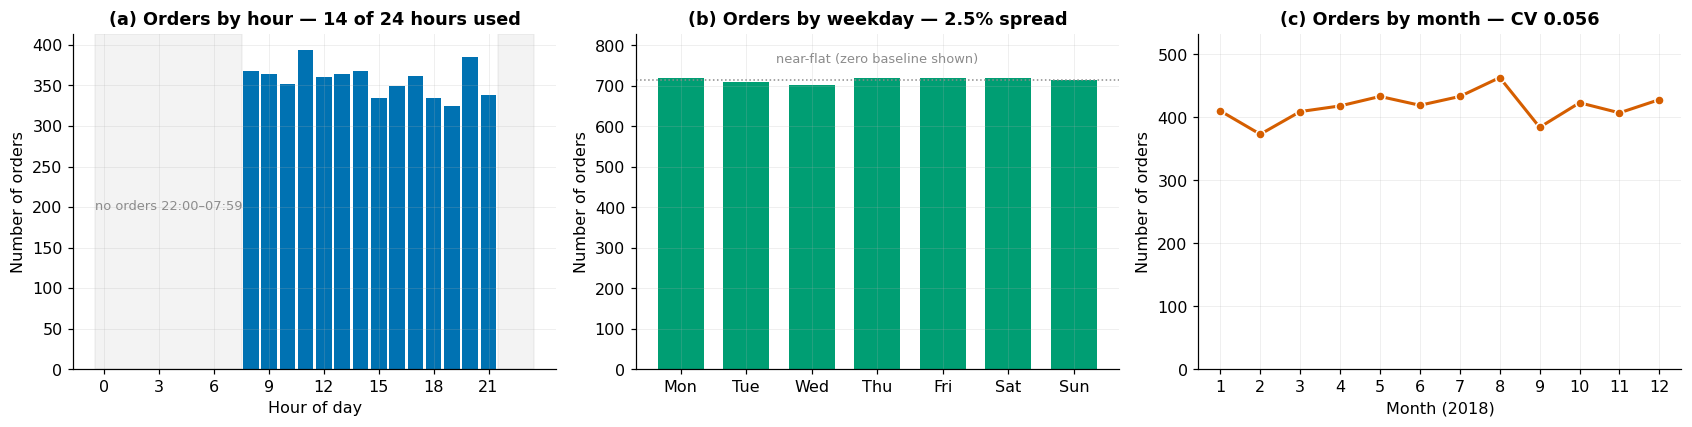

hours used: 14/24 (missing [0, 1, 2, 3, 4, 5, 6, 7, 22, 23])
weekday range 702–720 (spread 2.5%); month peak 8=463, trough 2=373, CV 0.056


In [8]:
order_dow = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
hr  = orders['order_dt'].dt.hour.value_counts().reindex(range(24), fill_value=0)
dow = orders['order_dt'].dt.day_name().value_counts().reindex(order_dow)
mth = orders.groupby(orders['order_dt'].dt.month).size().reindex(range(1,13))

fig, ax = plt.subplots(1, 3, figsize=(15.5, 4))
bars = ax[0].bar(range(24), hr.values, color=[OK['blue'] if v>0 else OK['grey'] for v in hr.values], width=0.85)
ax[0].set(title='(a) Orders by hour — 14 of 24 hours used', xlabel='Hour of day', ylabel='Number of orders', xticks=range(0,24,3))
ax[0].axvspan(-0.5, 7.5, color=OK['grey'], alpha=0.10); ax[0].axvspan(21.5, 23.5, color=OK['grey'], alpha=0.10)
ax[0].annotate('no orders 22:00–07:59', xy=(3.5, hr.max()*0.5), fontsize=8.5, ha='center', color=OK['grey'])

ax[1].bar(order_dow, dow.values, color=OK['green'], width=0.7)
ax[1].set(title=f'(b) Orders by weekday — {(dow.max()-dow.min())/dow.mean()*100:.1f}% spread', xlabel='', ylabel='Number of orders', ylim=(0, dow.max()*1.15))
ax[1].set_xticklabels([d[:3] for d in order_dow]); ax[1].axhline(dow.mean(), color=OK['grey'], ls=':', lw=1)
ax[1].annotate('near-flat (zero baseline shown)', xy=(3, dow.mean()), xytext=(3, dow.max()*1.05), ha='center', fontsize=8.5, color=OK['grey'])

ax[2].plot(range(1,13), mth.values, marker='o', color=OK['verm'], lw=2, mec='white')
ax[2].set(title=f'(c) Orders by month — CV {mth.std()/mth.mean():.3f}', xlabel='Month (2018)', ylabel='Number of orders', xticks=range(1,13), ylim=(0, mth.max()*1.15))
fig.tight_layout(); plt.show()
print(f"hours used: {int((hr>0).sum())}/24 (missing {sorted(hr[hr==0].index.tolist())})")
print(f"weekday range {dow.min()}–{dow.max()} (spread {(dow.max()-dow.min())/dow.mean()*100:.1f}%); "
      f"month peak {mth.idxmax()}={mth.max()}, trough {mth.idxmin()}={mth.min()}, CV {mth.std()/mth.mean():.3f}")

**Interpretation.** All three time axes are implausibly flat for real retail: orders
occur only 08:00–21:59 (14 of 24 hours), weekday volume varies just 2.5% (702–720/day,
with **zero baselines so the flatness is not exaggerated**), and monthly volume has a
coefficient of variation of only 0.056 (Aug peak 463, Feb trough 373). **Limitation:**
these are order-timestamp based; delivery dates spill 87 records into early 2019, so
delivery-time charts would need a 2019 caveat. This flatness is signature evidence for
Finding 1.

### Figure 5: Review or text behaviour

**Question:** How are ratings distributed, does helpful-voting look organic, and does
review length track rating?
**Observation unit / denominator:** one row per review; n = 7,000.
**Tables / join keys:** product_reviews only (no join).
**Interpretation / limitation:** see below the figure.

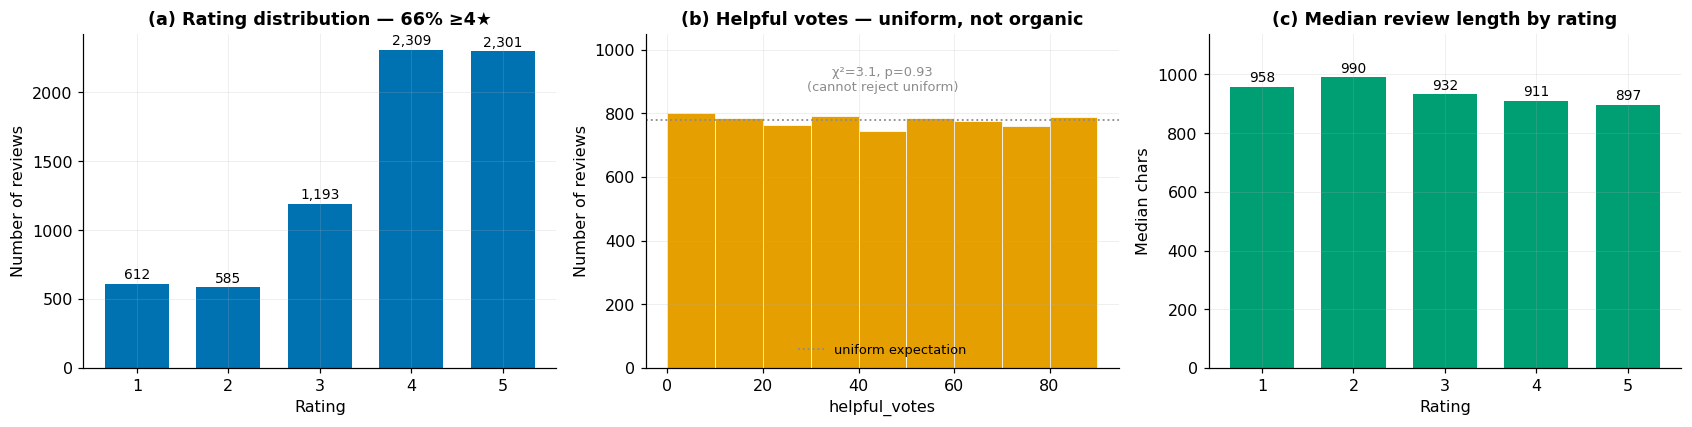

ratings: {1: 612, 2: 585, 3: 1193, 4: 2309, 5: 2301} | mean 3.729
helpful_votes: min 0 max 89 median 45; uniformity χ²=3.14 p=0.925
median length by rating: {1: 958.0, 2: 990.0, 3: 932.0, 4: 911.0, 5: 897.0} → slightly inverted (1★ longest)
non-Latin script: 276/7000 (3.9%), 13 languages


In [9]:
rc = reviews['rating'].value_counts().reindex([1,2,3,4,5])
hv = reviews['helpful_votes']
ml = reviews.groupby('rating')['review_length_chars'].median().reindex([1,2,3,4,5])

fig, ax = plt.subplots(1, 3, figsize=(15.5, 4))
ax[0].bar(rc.index, rc.values, color=OK['blue'], width=0.7)
for i,v in zip(rc.index, rc.values): ax[0].annotate(f'{v:,}', (i,v), xytext=(0,3), textcoords='offset points', ha='center', fontsize=9)
ax[0].set(title=f'(a) Rating distribution — {(reviews.rating>=4).mean()*100:.0f}% ≥4★', xlabel='Rating', ylabel='Number of reviews', xticks=[1,2,3,4,5])

ax[1].hist(hv, bins=np.arange(0,100,10), color=OK['orange'], edgecolor='white', linewidth=0.5)
ax[1].axhline(len(hv)/9, color=OK['grey'], ls=':', lw=1.2, label='uniform expectation')
ax[1].set(title='(b) Helpful votes — uniform, not organic', xlabel='helpful_votes', ylabel='Number of reviews', ylim=(0, len(hv)/9*1.35))
chi_hv, p_hv = stats.chisquare(pd.cut(hv, bins=np.arange(0,100,10), right=False).value_counts().sort_index().values)
ax[1].annotate(f'χ²={chi_hv:.1f}, p={p_hv:.2f}\n(cannot reject uniform)', xy=(45, len(hv)/9*1.12), ha='center', fontsize=8.5, color=OK['grey'])
ax[1].legend(loc='lower center', fontsize=8.5)

ax[2].bar(ml.index, ml.values, color=OK['green'], width=0.7)
for i,v in zip(ml.index, ml.values): ax[2].annotate(f'{v:.0f}', (i,v), xytext=(0,3), textcoords='offset points', ha='center', fontsize=9)
ax[2].set(title='(c) Median review length by rating', xlabel='Rating', ylabel='Median chars', xticks=[1,2,3,4,5], ylim=(0, ml.max()*1.15))
fig.tight_layout(); plt.show()
print("ratings:", rc.to_dict(), f"| mean {reviews['rating'].mean():.3f}")
print(f"helpful_votes: min {hv.min()} max {hv.max()} median {hv.median():.0f}; uniformity χ²={chi_hv:.2f} p={p_hv:.3f}")
print("median length by rating:", ml.round(0).to_dict(), "→ slightly inverted (1★ longest)")
print(f"non-Latin script: {int((reviews.contains_non_latin_script=='True').sum())}/7000 "
      f"({(reviews.contains_non_latin_script=='True').mean()*100:.1f}%), {reviews['language_code'].nunique()} languages")

**Interpretation.** Ratings lean positive (66% ≥4★, mean 3.73). `helpful_votes` is
statistically **uniform** on 0–89 (χ² = 3.1 across nine buckets, p = 0.93) — organic
helpfulness is heavily right-skewed, so this is a generation artefact (fourth synthetic
signature, Finding 1). Review length is flat-to-slightly-inverted across ratings
(1★ median 958 chars vs 5★ 897), consistent with the near-zero rating–length
correlation in Figure 2. **Limitation:** only 3.9% of reviews are genuinely non-Latin
(276/7,000 across 13 languages), so language is a minor dimension here.

### Figure 6: Delivery or operational performance

**Question:** Where is the on-time signal — warehouse, service level, or nowhere?
**Observation unit / denominator:** one row per completed order; n = 5,000; 531 late
(10.6%). **All orders are Completed/Delivered in this export — state as a caveat.**
**Tables / join keys:** deliveries ⋈ orders on `order_id` (1:1) to attach
`nearest_warehouse` and `expedited_delivery`. **Join #4.**
**Interpretation / limitation:** see below the figure.

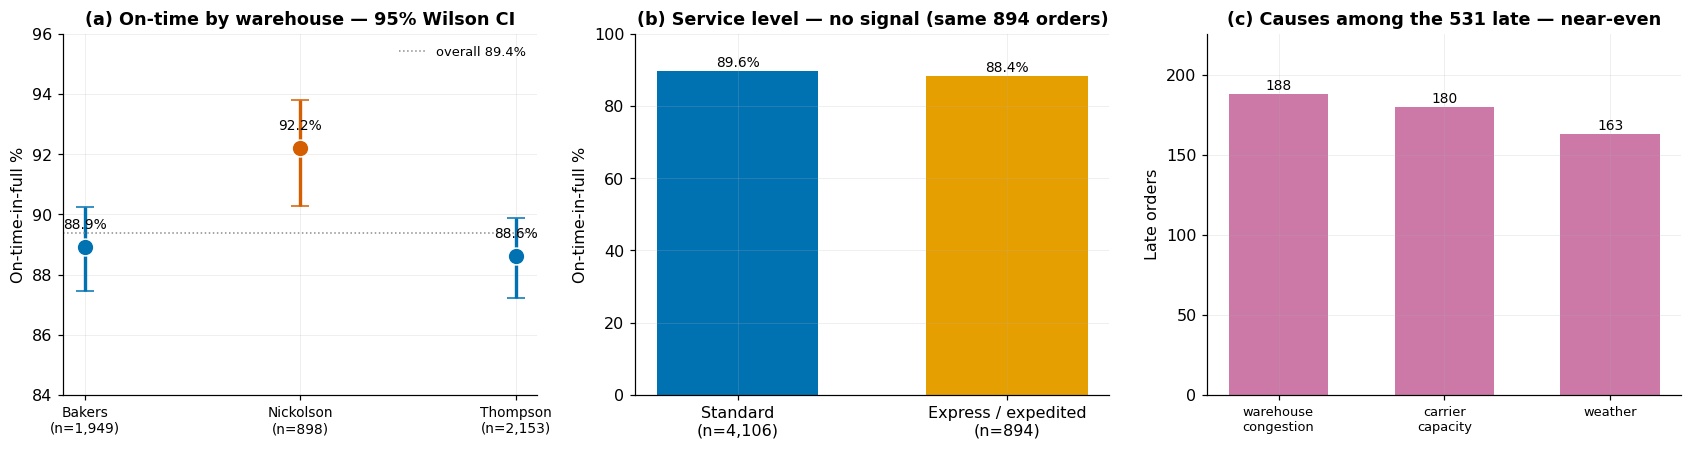

On-time-in-full by warehouse (95% Wilson CI):


,n,on_time_%,wilson_lo_%,wilson_hi_%
warehouse,,,,
Bakers,1949,88.9,87.4,90.2
Nickolson,898,92.2,90.3,93.8
Thompson,2153,88.6,87.2,89.9


overall on-time 89.38% (4469/5000)
Nickolson 92.2% (828/898) vs others 88.8% (3641/4102) → z=3.03, p=0.0024
service_level: {'Express': '88.4%', 'Standard': '89.6%'} | expedited==Express? True
carrier on-time %: {'AusPost': 89.8, 'DHL': 89.4, 'Direct Freight': 88.0, 'StarTrack': 90.3}


In [10]:
dd = deliveries.merge(orders[['order_id','nearest_warehouse','expedited_delivery']], on='order_id', how='left')
dd['ontime'] = (dd['on_time_in_full']=='True').astype(int)
overall = dd['ontime'].mean()

fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.2))
# (a) warehouse with Wilson CIs
wh = ['Bakers','Nickolson','Thompson']
pts = [(w,)+wilson(dd[dd.nearest_warehouse==w]['ontime'].sum(), (dd.nearest_warehouse==w).sum()) for w in wh]
for i,(w,p,lo,hi) in enumerate(pts):
    c = OK['verm'] if w=='Nickolson' else OK['blue']
    ax[0].errorbar(i, p*100, yerr=[[ (p-lo)*100],[(hi-p)*100]], fmt='o', ms=11, color=c, mec='white', elinewidth=2.2, capsize=6)
    ax[0].annotate(f'{p*100:.1f}%', (i,p*100), xytext=(0,12), textcoords='offset points', ha='center', fontsize=9)
ax[0].axhline(overall*100, color=OK['grey'], ls=':', lw=1, label=f'overall {overall*100:.1f}%')
ax[0].set_xticks(range(3)); ax[0].set_xticklabels([f"{w}\n(n={(dd.nearest_warehouse==w).sum():,})" for w in wh], fontsize=9)
ax[0].set(ylabel='On-time-in-full %', ylim=(84,96), title='(a) On-time by warehouse — 95% Wilson CI')
ax[0].legend(fontsize=8.5)
# (b) service/expedited null on a 0–100 scale so the null is honest
sl = dd.groupby('service_level')['ontime'].mean()*100
ax[1].bar(['Standard\n(n=4,106)','Express / expedited\n(n=894)'], [sl['Standard'], sl['Express']], color=[OK['blue'],OK['orange']], width=0.6)
for i,v in enumerate([sl['Standard'], sl['Express']]): ax[1].annotate(f'{v:.1f}%', (i,v), xytext=(0,3), textcoords='offset points', ha='center', fontsize=9)
ax[1].set(ylabel='On-time-in-full %', ylim=(0,100), title='(b) Service level — no signal (same 894 orders)')
# (c) delay-reason composition
dr = deliveries[deliveries.on_time_in_full=='False']['delay_reason'].value_counts()
ax[2].bar(dr.index, dr.values, color=OK['purple'], width=0.6)
for i,v in enumerate(dr.values): ax[2].annotate(f'{v}', (i,v), xytext=(0,3), textcoords='offset points', ha='center', fontsize=9)
ax[2].set(ylabel='Late orders', title='(c) Causes among the 531 late — near-even', ylim=(0, dr.max()*1.2))
ax[2].set_xticklabels([s.replace('_','\n') for s in dr.index], fontsize=8.5)
fig.tight_layout(); plt.show()

wh_tbl = pd.DataFrame([{'warehouse':w, 'n':int((dd.nearest_warehouse==w).sum()),
                        'on_time_%':round(p*100,1), 'wilson_lo_%':round(lo*100,1), 'wilson_hi_%':round(hi*100,1)}
                       for (w,p,lo,hi) in pts]).set_index('warehouse')
print("On-time-in-full by warehouse (95% Wilson CI):"); display(wh_tbl)
nk = dd[dd.nearest_warehouse=='Nickolson']['ontime']; oth = dd[dd.nearest_warehouse!='Nickolson']['ontime']
z,p = two_prop_z(nk.sum(), len(nk), oth.sum(), len(oth))
print(f"overall on-time {overall*100:.2f}% ({dd.ontime.sum()}/{len(dd)})")
print(f"Nickolson {nk.mean()*100:.1f}% ({nk.sum()}/{len(nk)}) vs others {oth.mean()*100:.1f}% ({oth.sum()}/{len(oth)}) → z={z:.2f}, p={p:.4f}")
print("service_level:", {k:f'{v:.1f}%' for k,v in sl.items()},
      "| expedited==Express?", bool((( (dd.expedited_delivery=='True') == (dd.service_level=='Express') ).all())))
print("carrier on-time %:", {k:round(v*100,1) for k,v in dd.groupby('carrier')['ontime'].mean().items()})

In [11]:
# Robustness (D-1): does the Nickolson edge survive conditioning on measured covariates?
import statsmodels.api as sm
reg = dd.copy()
reg['express'] = (reg['service_level']=='Express').astype(int)
reg['wh_Nickolson'] = (reg['nearest_warehouse']=='Nickolson').astype(int)
reg['wh_Bakers']    = (reg['nearest_warehouse']=='Bakers').astype(int)   # Thompson = reference
X = sm.add_constant(reg[['shipping_distance_km','fulfilment_hours','tracking_event_count','express','wh_Nickolson','wh_Bakers']])
m = sm.Logit(reg['ontime'], X).fit(disp=0)
tbl = m.summary2().tables[1][['Coef.','Std.Err.','z','P>|z|']].round(4)
print("Logistic regression: on_time_in_full ~ covariates + warehouse fixed effects\n")
display(tbl)
print(f"\nNickolson: coef {m.params['wh_Nickolson']:.3f}, OR {np.exp(m.params['wh_Nickolson']):.2f}, p={m.pvalues['wh_Nickolson']:.4f} "
      f"→ edge SURVIVES; measured covariates (distance, fulfilment, tracking, service) are all non-significant.")
print("Covariate means by warehouse (balance check):")
display(dd.groupby('nearest_warehouse').agg(fulfil_h=('fulfilment_hours','mean'), tracking=('tracking_event_count','mean'),
        dist_km=('shipping_distance_km','mean'), expedited_share=('expedited_delivery', lambda s:(s=='True').mean())).round(2))

Logistic regression: on_time_in_full ~ covariates + warehouse fixed effects



,Coef.,Std.Err.,z,P>|z|
const,1.8155,0.2011,9.0290,0.0000
shipping_distance_km,0.0019,0.0197,0.0968,0.9229
fulfilment_hours,0.0026,0.0022,1.1664,0.2434
tracking_event_count,0.0262,0.0230,1.1409,0.2539
express,-0.1263,0.1164,-1.0847,0.2781
wh_Nickolson,0.4198,0.1419,2.9571,0.0031
wh_Bakers,0.0275,0.0993,0.2774,0.7815



Nickolson: coef 0.420, OR 1.52, p=0.0031 → edge SURVIVES; measured covariates (distance, fulfilment, tracking, service) are all non-significant.
Covariate means by warehouse (balance check):


,fulfil_h,tracking,dist_km,expedited_share
nearest_warehouse,,,,
Bakers,37.54,6.02,4.95,0.17
Nickolson,37.54,5.92,4.92,0.18
Thompson,37.21,5.98,5.22,0.18


**Interpretation.** On-time-in-full is 89.4% overall. Only **warehouse** carries a
signal: Nickolson 92.2% (828/898) vs 88.8% elsewhere (two-proportion z = 3.03,
p = 0.002), and the gap **survives** a logistic regression controlling for distance,
fulfilment hours, tracking events and service level (OR = 1.52, p = 0.003) with all
covariates balanced across warehouses. Service level shows no signal — and because
`expedited_delivery=True` is exactly the same 894 orders as `service_level=Express`,
that is one null, not two. **Limitation:** every order here is Completed/Delivered (no
cancellations/returns), and an unobserved confound (staffing, routing) could still
explain Nickolson (supports Findings 5 and 7).

### Figure 7: Delivery economics (reinforces category 6)

**Question:** Does the retailer recoup delivery costs, and does that vary by service
tier?
**Observation unit / denominator:** one row per completed order; n = 5,000.
**Tables / join keys:** `delivery_charges` (orders) with `delivery_cost` (deliveries) on
`order_id` (1:1). **Join #5.**
**Interpretation / limitation:** see below the figure.

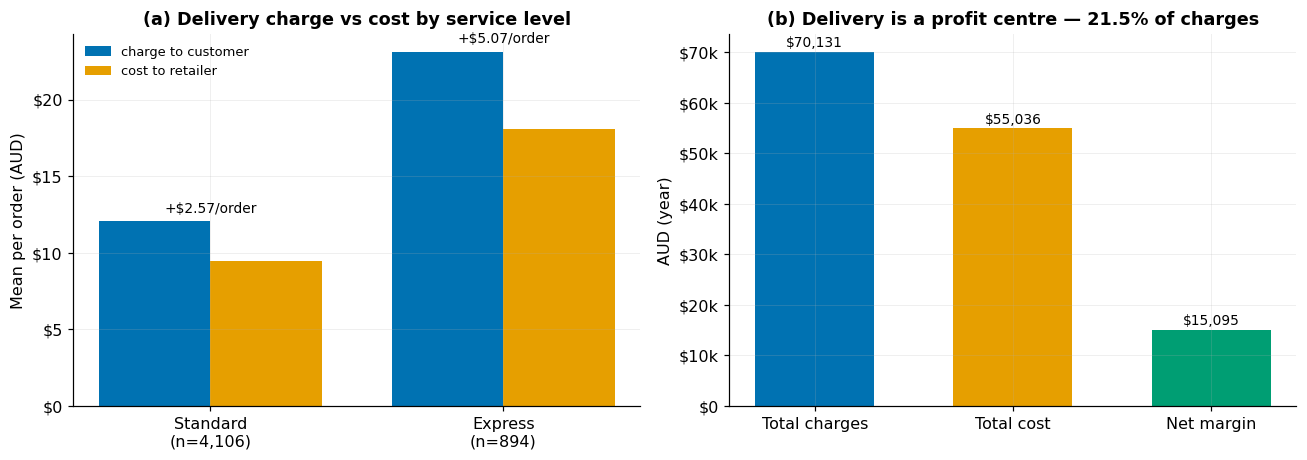

charges $70,130.71 − cost $55,035.78 = +$15,094.93  (21.5% of charges; 27% mark-up on cost)
per-order margin: {'Standard': '$2.57', 'Express': '$5.07'}


In [12]:
dp = deliveries[['order_id','delivery_cost','service_level']].merge(orders[['order_id','delivery_charges']], on='order_id', how='left')
tot_ch, tot_co = dp['delivery_charges'].sum(), dp['delivery_cost'].sum()
by = dp.groupby('service_level').agg(n=('order_id','size'), charge=('delivery_charges','mean'), cost=('delivery_cost','mean'))
by['margin'] = by['charge'] - by['cost']

fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
lv = ['Standard','Express']; xx = np.arange(2); w = 0.38
ax[0].bar(xx-w/2, by.loc[lv,'charge'], w, color=OK['blue'], label='charge to customer')
ax[0].bar(xx+w/2, by.loc[lv,'cost'],   w, color=OK['orange'], label='cost to retailer')
for i,l in enumerate(lv):
    ax[0].annotate(f"+${by.loc[l,'margin']:.2f}/order", (i, by.loc[l,'charge']), xytext=(0,6), textcoords='offset points', ha='center', fontsize=9)
ax[0].set_xticks(xx); ax[0].set_xticklabels([f'{l}\n(n={int(by.loc[l,"n"]):,})' for l in lv])
ax[0].set(ylabel='Mean per order (AUD)', title='(a) Delivery charge vs cost by service level')
ax[0].yaxis.set_major_formatter(FuncFormatter(aud)); ax[0].legend(fontsize=8.5)

ax[1].bar(['Total charges','Total cost','Net margin'], [tot_ch, tot_co, tot_ch-tot_co],
          color=[OK['blue'], OK['orange'], OK['green']], width=0.6)
for i,v in enumerate([tot_ch, tot_co, tot_ch-tot_co]): ax[1].annotate(f'${v:,.0f}', (i,v), xytext=(0,3), textcoords='offset points', ha='center', fontsize=9)
ax[1].set(ylabel='AUD (year)', title=f'(b) Delivery is a profit centre — {(tot_ch-tot_co)/tot_ch*100:.1f}% of charges')
ax[1].yaxis.set_major_formatter(FuncFormatter(aud))
fig.tight_layout(); plt.show()
print(f"charges ${tot_ch:,.2f} − cost ${tot_co:,.2f} = +${tot_ch-tot_co:,.2f}  "
      f"({(tot_ch-tot_co)/tot_ch*100:.1f}% of charges; {(tot_ch-tot_co)/tot_co*100:.0f}% mark-up on cost)")
print("per-order margin:", {l: f"${by.loc[l,'margin']:.2f}" for l in lv})

**Interpretation.** Delivery is a small **profit centre**: charges \$70,131 against
cost \$55,036 leaves +\$15,095 — 21.5% of charges (a 27% mark-up on cost). Express earns
\$5.07/order versus Standard \$2.57/order. **Limitation:** `delivery_cost` is almost
certainly a direct-cost field that excludes overheads (warehouse rent, staff), so the
true margin is an upper bound; the finding is that expedited pricing *looks*
under-monetised relative to its per-order margin, not a recommendation (supports
Finding 6).

### Figure 8: Category co-purchase lift (reinforces category 3)

**Question:** Do product categories cluster into baskets — are there natural cross-sell
relationships?
**Observation unit / denominator:** unordered category pair, computed over 5,000 orders
(distinct categories per order).
**Tables / join keys:** `order_items` ⋈ `products` on `product_id`, then aggregated per
order (deduplicated categories, so no row multiplication). Lift = P(A∩B)/(P(A)-P(B)).
**Interpretation / limitation:** see below the figure.

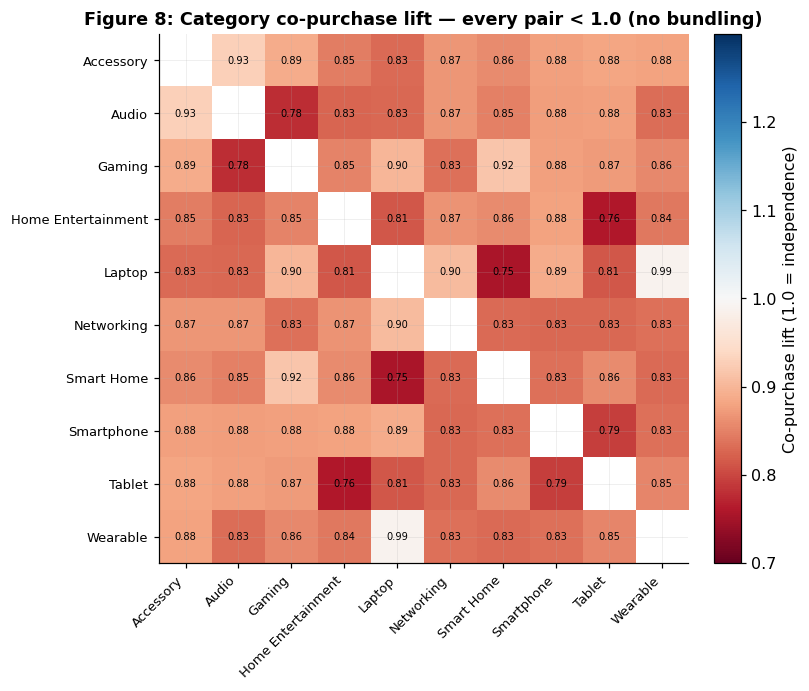

lift range [0.754, 0.988]; pairs with lift ≥ 1.0: 0/45
highest pair: Laptop+Wearable = 0.988; mean distinct categories/order = 2.76


In [13]:
ip = order_items.merge(products[['product_id','category']], on='product_id', how='left')
order_cats = ip.groupby('order_id')['category'].apply(lambda s: set(s))
cats = sorted(products['category'].unique()); K = len(cats); N = len(order_cats)
single, pair = Counter(), Counter()
for cs in order_cats:
    for c in cs: single[c] += 1
    for a,b in combinations(sorted(cs),2): pair[(a,b)] += 1
M = np.full((K,K), np.nan)
best = (None,0)
for i,a in enumerate(cats):
    for j,b in enumerate(cats):
        if i<j:
            key=(a,b); lift=(pair[key]/N)/((single[a]/N)*(single[b]/N))
            M[i,j]=M[j,i]=lift
            if lift>best[1]: best=(key,lift)

fig, ax = plt.subplots(figsize=(7.6, 6.4))
im = ax.imshow(M, cmap='RdBu', norm=TwoSlopeNorm(vmin=0.70, vcenter=1.0, vmax=1.30))
ax.set_xticks(range(K)); ax.set_xticklabels(cats, rotation=45, ha='right', fontsize=8.5)
ax.set_yticks(range(K)); ax.set_yticklabels(cats, fontsize=8.5)
for i in range(K):
    for j in range(K):
        if not np.isnan(M[i,j]): ax.text(j, i, f'{M[i,j]:.2f}', ha='center', va='center', fontsize=6.5, color='black')
cbar = fig.colorbar(im, fraction=0.046, pad=0.04); cbar.set_label('Co-purchase lift (1.0 = independence)')
ax.set_title('Figure 8: Category co-purchase lift — every pair < 1.0 (no bundling)')
fig.tight_layout(); plt.show()
allv = M[~np.isnan(M)]
print(f"lift range [{allv.min():.3f}, {allv.max():.3f}]; pairs with lift ≥ 1.0: {int((allv>=1.0).sum()//2)}/{K*(K-1)//2}")
print(f"highest pair: {best[0][0]}+{best[0][1]} = {best[1]:.3f}; mean distinct categories/order = {order_cats.apply(len).mean():.2f}")

**Interpretation.** There is **no basket bundling structure**: all 45 category-pair
lifts fall below 1.0 (0.75–0.99); even the strongest, Laptop+Wearable, reaches only
0.99 — no pair exceeds statistical independence. A cooler-than-neutral map everywhere is
itself consistent with near-independent category assignment (another synthetic trait).
**Limitation:** the ten categories are broad, so within-category substitution could mask
finer between-product complements; the finding is about *category-level* cross-sell
(supports Finding 9).

## 3. Ten evidence-based findings

Each finding states **grain - magnitude/denominator - context - uncertainty or
alternative - proportionate implication**, and reports associations as associations.
The category revenue/margin table for Finding 10 is computed below.

In [14]:
ipc = order_items.merge(products[['product_id','category','unit_cost']], on='product_id', how='left')
ipc['line_cost'] = ipc['unit_cost'] * ipc['quantity']
cat = ipc.groupby('category').agg(revenue=('line_revenue','sum'), cost=('line_cost','sum'))
cat['gross_margin_%'] = (1 - cat['cost']/cat['revenue'])*100
cat = cat.sort_values('revenue', ascending=False)
out = cat.copy(); out['revenue']=(out['revenue']/1e6).round(2); out['cost']=(out['cost']/1e6).round(2); out['gross_margin_%']=out['gross_margin_%'].round(1)
out.columns = ['revenue ($M)','cost ($M)','gross margin %']
display(out)
print(f"revenue range {cat['revenue'].max()/cat['revenue'].min():.1f}× across categories; "
      f"top category = {cat['revenue'].max()/cat['revenue'].sum()*100:.1f}% of revenue; "
      f"gross margin band {cat['gross_margin_%'].min():.1f}–{cat['gross_margin_%'].max():.1f}%")

,revenue ($M),cost ($M),gross margin %
category,,,
Laptop,2.85,1.79,37.3
Home Entertainment,2.70,1.65,38.9
Gaming,1.96,1.26,35.7
Smartphone,1.60,0.98,39.1
Tablet,1.54,0.94,39.1
Networking,1.26,0.78,38.4
Audio,1.26,0.79,37.6
Wearable,1.16,0.73,37.6
Smart Home,0.87,0.53,39.7


revenue range 5.0× across categories; top category = 18.1% of revenue; gross margin band 35.7–39.7%


1. **Synthetic-data signatures bound every interpretation.** *(Grain: mixed — order
5,000, review 7,000, customer 500.)* Orders span only 14 of 24 hours (08:00–21:59);
weekday volume varies 2.5% (702–720/day); `helpful_votes` is statistically uniform on
0–89 (χ² = 3.1, p = 0.93); and `prior_12m_orders` barely correlates with observed 2018
orders (r = 0.05). Four independent flat/disconnected signals, where real e-commerce
shows late-night trade, weekend peaks, heavy-tailed helpfulness and persistent customer
behaviour. *Alternative:* any one could be benign; four together indicate generated
data. *Implication:* every finding below is a description of **this dataset**, not a
generalisable business claim. *(Figures 4, 5b; §1.2.)*

2. **Historical customer fields do not predict observed behaviour.** *(Grain: customer,
n = 500.)* `prior_12m_orders` vs observed 2018 orders r = 0.05; `lifetime_value_before_period`
vs observed 2018 revenue r = 0.02. These are the natural CLV/segmentation seeds.
*Alternative:* a genuine year-on-year behaviour shift, implausible across all 500
customers simultaneously. *Implication:* build segmentation/CLV on **observed** order
behaviour, not the supplied historical fields, which carry ~no signal. *(Figure 3d.)*

3. **Order value is a basket-composition property, not a customer-type one.** *(Grain:
order, n = 5,000.)* Mean quantity rises Q1 2.62 → Q4 5.34 and distinct products
2.22 → 3.84 across value quartiles; average item price is the strongest correlate
(r = 0.73 > quantity 0.58 > breadth 0.49), while customer-segment mix is flat (AOV
\$2,788–\$2,933, ~5% spread). *Alternative:* order value is partly a mechanical function
of line items, so the value–quantity link is observational, and *expensive items* matter
more than *more* items. *Implication:* AOV levers are assortment and price-mix, not
customer-segment targeting. *(Figure 3a–c.)*

4. **Stated value-perception is the only material rating correlate; delivery is not.**
*(Grain: review, n = 7,000.)* Mean rating 3.75 (good_value, n = 6,118) vs 3.57
(poor_value, n = 882) — gap 0.18, Welch t = 4.0, p < 0.001 — roughly 3× the
delivery-lateness gap (0.06, ns) and far above the length correlation (−0.04); and it is
not a recode (581/882 poor_value reviews rate ≥4★). *Alternative:* value_experience and
rating are co-reported by the same reviewer (shared-method variance), so this is
association, not a driver. *Implication:* rating variation aligns with value perception,
not delivery ops; the effect is small and non-causal. *(Figure 2.)*

5. **The Nickolson warehouse out-performs on on-time delivery.** *(Grain: delivery/order,
n = 5,000.)* Nickolson on-time 92.2% (828/898) vs 88.8% elsewhere (3,641/4,102);
two-proportion z = 3.03, p = 0.002; the edge survives a logistic regression controlling
for distance, fulfilment hours, tracking events and service level (OR = 1.52, p = 0.003),
with covariates balanced across warehouses. *Alternative:* an unobserved confound
(staffing, routing, order mix) absent from the schema. *Implication:* Nickolson's
practice is worth investigating; the gap resists explanation by the recorded covariates.
*(Figure 6a.)*

6. **Delivery is a small profit centre, and Express looks under-priced relative to
margin.** *(Grain: delivery/order, n = 5,000.)* Charges \$70,131 vs cost \$55,036 =
+\$15,095 (21.5% of charges; 27% mark-up on cost); Express earns \$5.07/order (n = 894)
vs Standard \$2.57/order (n = 4,106). *Alternative:* `delivery_cost` likely excludes
overheads, so the true margin is smaller. *Implication:* if margin holds at fully-loaded
cost, Express pricing is under-monetised relative to its per-order margin — a pricing
review, not a conclusion. *(Figure 7.)*

7. **On-time delivery has no service or carrier signal, and evenly-split causes.**
*(Grain: delivery, n = 5,000.)* 89.4% on-time overall; Express/expedited (the same 894
orders — `service_level=Express` ⟺ `expedited_delivery=True`) 88.4% vs Standard 89.6%
(Δ −1.2pp, ns); carriers span only 88.0–90.3%; the 531 late orders split near-evenly
across warehouse_congestion 188 / carrier_capacity 180 / weather 163. *Alternative:* the
real driver is a variable absent from the schema. *Implication:* a Task-6 delay
classifier cannot lean on the obvious operational features. *(Figure 6b–c.)*

8. **Revenue is moderately concentrated, not whale-dependent.** *(Grain: order,
n = 5,000.)* Median \$2,410 vs mean \$2,858, skew 1.49; the top 1% of orders (n = 50)
hold 4.0% of revenue and the top 10% about 26% (Gini 0.39). *Alternative:* the mild
mean–median gap could be a generation choice rather than genuine heterogeneity.
*Implication:* report AOV with medians; revenue is not fragile to losing a few large
orders. *(Figure 1.)*

9. **There is no category co-purchase structure.** *(Grain: category pair, over 5,000
orders.)* All 45 category-pair lifts are below 1.0 (0.75–0.99); the highest,
Laptop+Wearable, reaches only 0.99. *Alternative:* the ten categories are broad enough
that within-category substitution could mask finer complements. *Implication:* a naïve
cross-sell recommender on these baskets would find no natural category complements to
promote. *(Figure 8.)*

10. **Category revenue is concentrated while gross margin is uniform.** *(Grain: order
item, n = 15,739.)* Line revenue ranges ~5× across categories — Laptop \$2.85M
(37% gross margin) down to Accessory \$0.57M (38%) — yet gross margin sits in a narrow
36–40% band for all ten. *Alternative:* margin uses catalogue `unit_cost`, not landed
cost, so absolute margin is an upper bound. *Implication:* category mix moves revenue but
not blended margin, so a revenue-growth lever and a margin lever are effectively
decoupled in this catalogue. *(Category revenue/margin table above.)*

## 4. Five future machine-learning questions

Five questions across three problem types (binary classification, regression/time-series,
unsupervised). Each uses only **decision-time** predictors — a value known before the
event being predicted — and names its leakage/fairness risk. No models are trained.

### MLQ-1: Will an order miss its on-time-in-full promise? *(binary classification)*

| Element | Response |
|---|---|
| EDA evidence | Figure 6 / Finding 7 — 10.6% late (531/5,000); warehouse is the only signal (Nickolson OR 1.52), service/carrier flat. |
| Business decision | At dispatch, whether to flag an order for pro-active intervention (re-route, notify, upgrade). |
| Problem type & unit | Binary classification; unit = order/delivery. |
| Target | `on_time_in_full` (False = late). |
| Decision-time predictors | `nearest_warehouse`, `service_level`, `carrier`, `shipping_distance_km`, `promised_days`, basket size (items, quantity), `season`, dispatch weekday/hour — all known at dispatch. |
| Validation & metric | Time-ordered split (train early months → test later); PR-AUC and recall at fixed precision, because of 10.6% class imbalance. |
| Leakage / fairness risk | Exclude post-outcome fields (`delivered_date`, `delay_days`, `delay_reason`, `on_time_in_full`). Finding 7 predicts a low ceiling; monitor fairness across warehouses so Nickolson's edge is not encoded as customer penalty. |


### MLQ-2: How many orders (and how much revenue) next week? *(regression / time-series)*

| Element | Response |
|---|---|
| EDA evidence | Figure 4 / Finding 1 — flat weekday spread (2.5%) and mild seasonality (monthly CV 0.056, Aug peak). |
| Business decision | Staffing and inventory capacity planning. |
| Problem type & unit | Regression / time-series forecasting; unit = day (or ISO week). |
| Target | Daily order count and daily revenue. |
| Decision-time predictors | Calendar features known in advance — month, weekday, `season`, public-holiday flags, trend index. |
| Validation & metric | Forward-chaining (rolling-origin) CV; MAE / MAPE against a seasonal-naïve baseline. |
| Leakage / fairness risk | Use only past-dated aggregates; Finding 1's flatness means the model may not beat the seasonal-naïve baseline, and a single 2018 year limits training — report the baseline honestly. |


### MLQ-3: What rating will a review text receive? *(ordinal regression / NLP)*

| Element | Response |
|---|---|
| EDA evidence | Figure 5 / Finding 4 — length–rating r = −0.04 and writing-style ≈ independent of rating (χ² p = 0.27), so text signal is weak. |
| Business decision | Prioritise incoming reviews for moderation/response. |
| Problem type & unit | Ordinal regression (or ordinal classification); unit = review. |
| Target | `rating` (1–5, ordered). |
| Decision-time predictors | Features from `review_body_clean` (TF-IDF/embeddings), `review_length_chars`, `writing_style`, `language_code` — all present at review time. |
| Validation & metric | Group-by-product split (avoid product leakage); quadratic-weighted-kappa and MAE for the ordinal target. |
| Leakage / fairness risk | Do not use `value_experience`/`delivery_experience` as predictors — they are co-reported with the rating (shared-method leakage); guard against language bias given 13 languages. |


### MLQ-4: What natural customer segments exist for targeting? *(unsupervised)*

| Element | Response |
|---|---|
| EDA evidence | Findings 2 & 3 — supplied `customer_segment` is flat vs order value and historical fields carry ~no signal (r ≤ 0.05). |
| Business decision | Design marketing segments that actually relate to behaviour. |
| Problem type & unit | Unsupervised clustering; unit = customer (n = 500). |
| Objective | Discover segments from **observed** behaviour — observed order count/revenue, basket breadth, category mix, recency. |
| Decision-time predictors | Behavioural aggregates computed from the observed 2018 window (not `prior_12m_orders`/`lifetime_value_before_period`). |
| Validation & metric | Cluster stability via bootstrap + silhouette; validate against held-out behaviour and business interpretability. |
| Leakage / fairness risk | Exclude the low-signal historical fields (Finding 2); small n = 500 limits granularity, so prefer few, stable clusters. |


### MLQ-5: Which delivered orders will draw a poor-value review? *(binary classification)*

| Element | Response |
|---|---|
| EDA evidence | Figure 2 / Finding 4 — poor_value (882/7,000) carries the only material rating gap, but is weakly tied to observable order/delivery features. |
| Business decision | Trigger proactive outreach/goodwill after delivery, before the review lands (median order→review lag 29 days). |
| Problem type & unit | Binary classification; unit = order (with a review). |
| Target | `value_experience = poor_value`. |
| Decision-time predictors | Known by delivery, before the review: product category, price paid, discount used, order value, on-time outcome, warehouse/carrier. |
| Validation & metric | Group-by-customer, time-ordered split; ROC-AUC + recall at a service-capacity threshold. |
| Leakage / fairness risk | Exclude all review-time fields (rating, review text, `value_experience` itself); Finding 4 implies a modest ceiling; check fairness across segments and languages before any outreach action. |


## 5. Limitations and conclusion

**Limitations.** (1) The dataset is synthetic on at least four independent measures
(Finding 1), so findings describe this export and do not generalise to real trading.
(2) It is a single 2018 year, and every order is Completed/Delivered — there are no
cancellations, returns, or lost sales, so delivery findings are survivorship-limited.
(3) Margin uses catalogue `unit_cost`, not landed cost, so delivery and category margins
are upper bounds. (4) Reviews cover 4,017 of 5,000 orders and every review is a verified
purchase, so review-based findings carry a selection caveat. (5) `value_experience` and
`rating` are co-reported, and order value is partly a mechanical function of line items,
so the strongest associations are explicitly non-causal. (6) With 500 customers, any
segmentation is coarse.

**Conclusion.** Read against its synthetic frame, the data still yields a coherent,
decision-relevant picture: order value is a basket-composition property (driven more by
item price than breadth) rather than a customer-type one; the Nickolson warehouse holds
a real, covariate-resistant on-time edge; delivery is a small profit centre where
expedited pricing looks under-monetised; stated value-perception is the only material
rating correlate; and there is no category bundling structure. The most valuable
handoff to Task 6 is negative: the obvious operational and historical predictors are
null, so every ML question must be framed decision-time, leakage-aware, and with honest
feasibility caveats — which is exactly how §4 poses them.

## References

Course-supplied materials: `public_data_dictionary.csv` (field grains, types and
comparison rules) and the Group005 Task 1–4 solution (`Group005_solution.ipynb`,
`Group005_source_to_target_mapping.csv`) for the `MAP-…` / `VAL-…` provenance IDs cited
in §1. Libraries: pandas, NumPy, Matplotlib, SciPy, statsmodels. Colour palette:
Okabe & Ito (2008), colour-blind-safe qualitative set.